In [2]:
import numpy as np
import cv2 as cv
import glob
import os
import re

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Inputs
num_squares_x = 10                               # Number of chessboard squares along the x-axis
num_squares_y = 7                               # Number of chessboard squares along the y-axis
num_interior_corners_x = num_squares_x - 1      # Number of interior corners along x-axis
num_interior_corners_y = num_squares_y - 1      # Number of interior corners along y-axis
checker_width = 10.006                           # Checker width (in mm)

# Generate corresponding world points for this pose checkerboard
objp = np.zeros((num_interior_corners_x * num_interior_corners_y, 3), np.float32)
objp[:, :2] = np.mgrid[0:num_interior_corners_x, 0:num_interior_corners_y].T.reshape(-1, 2)
objp = objp * checker_width

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

image_dir = 'Data/camera'
# Natural sort: handles camerapose1, camerapose2, ..., camerapose10 correctly
def natural_sort_key(filepath):
    filename = os.path.basename(filepath)
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', filename)]

images = sorted(glob.glob(os.path.join(image_dir, '*.png')), key=natural_sort_key)
print(f"Found {len(images)} images")

for fname in images:
    img = cv.imread(fname)
    if img is None:
        print(f"Failed to read {fname}")
        continue
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (num_interior_corners_x, num_interior_corners_y), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)

        corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)
        print(f"Chessboard found in {os.path.basename(fname)}")
    else:
        print(f"Chessboard NOT found in {os.path.basename(fname)}")

print(f"\nSuccessfully detected {len(objpoints)} chessboards")

Found 16 images
Chessboard found in camerapose1.png
Chessboard found in camerapose2.png
Chessboard found in camerapose3.png
Chessboard found in camerapose4.png
Chessboard found in camerapose5.png
Chessboard found in camerapose6.png
Chessboard found in camerapose7.png
Chessboard found in camerapose8.png
Chessboard found in camerapose9.png
Chessboard found in camerapose10.png
Chessboard found in camerapose11.png
Chessboard found in camerapose12.png
Chessboard found in camerapose13.png
Chessboard found in camerapose14.png
Chessboard found in camerapose15.png
Chessboard found in camerapose16.png

Successfully detected 16 chessboards


Image                          Detected        Corners        
camerapose1.png                ✓ Yes           54             
camerapose2.png                ✓ Yes           54             
camerapose3.png                ✓ Yes           54             
camerapose4.png                ✓ Yes           54             
camerapose5.png                ✓ Yes           54             
camerapose6.png                ✓ Yes           54             
camerapose7.png                ✓ Yes           54             
camerapose8.png                ✓ Yes           54             
camerapose9.png                ✓ Yes           54             
camerapose10.png               ✓ Yes           54             
camerapose11.png               ✓ Yes           54             
camerapose12.png               ✓ Yes           54             
camerapose13.png               ✓ Yes           54             
camerapose14.png               ✓ Yes           54             
camerapose15.png               ✓ Yes           54      

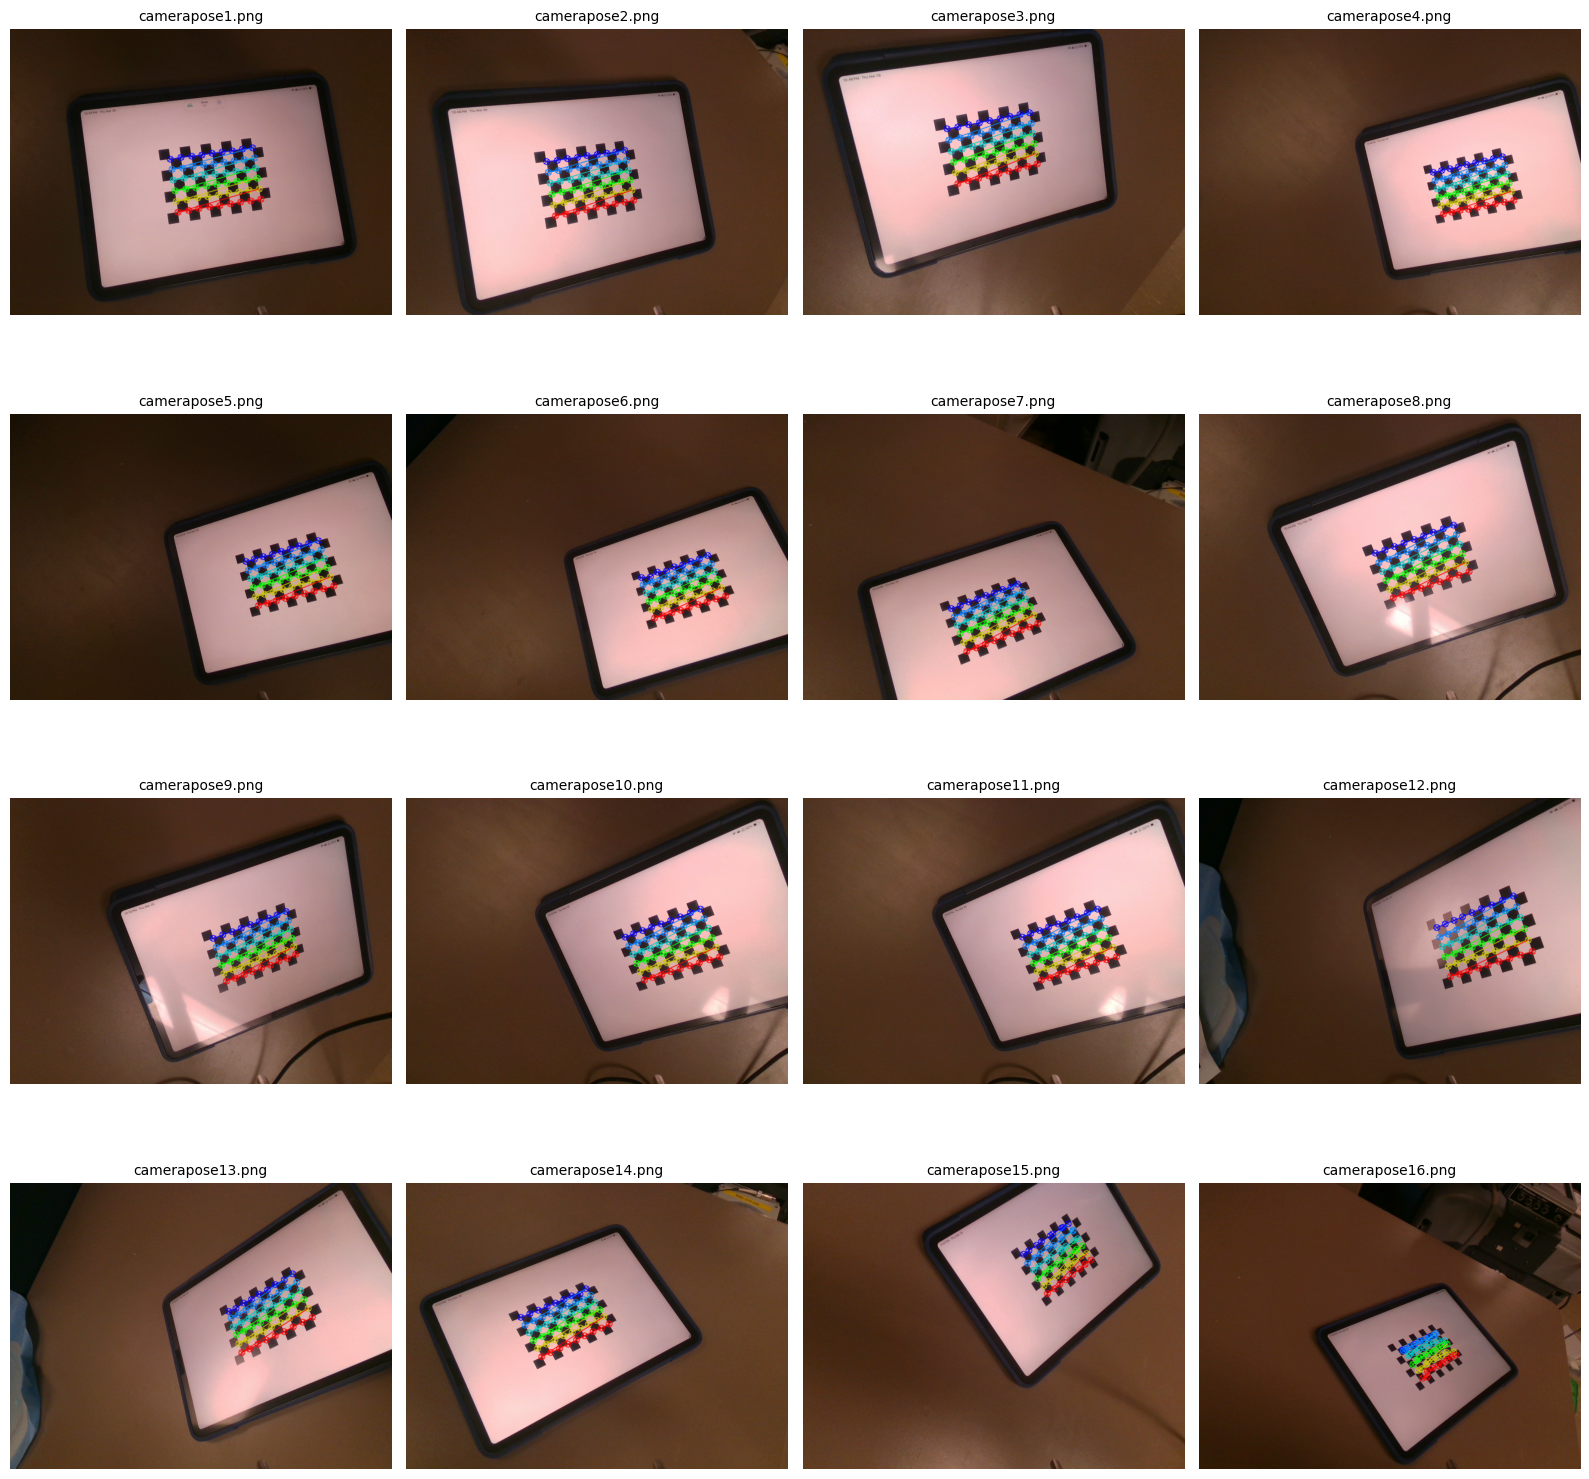


Detailed summary: 16 images successfully calibrated


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a summary of detection results
detection_results = []
for idx, fname in enumerate(images):
    img = cv.imread(fname)
    if img is None:
        continue
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    ret, corners = cv.findChessboardCorners(gray, (num_interior_corners_x, num_interior_corners_y), None)
    detection_results.append({
        'image': os.path.basename(fname),
        'detected': ret,
        'corners_count': len(corners) if ret else 0
    })

# Print summary table
print("=" * 70)
print(f"{'Image':<30} {'Detected':<15} {'Corners':<15}")
print("=" * 70)
for result in detection_results:
    status = "✓ Yes" if result['detected'] else "✗ No"
    print(f"{result['image']:<30} {status:<15} {result['corners_count']:<15}")
print("=" * 70)
print(f"Total: {sum(1 for r in detection_results if r['detected'])} / {len(detection_results)} detected")

# Visualize detected corners on all successful images
detected_count = sum(1 for r in detection_results if r['detected'])
cols = 4
rows = (detected_count + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

plot_idx = 0
for fname, result in zip(images, detection_results):
    if result['detected']:
        img = cv.imread(fname)
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        
        # Redraw corners for visualization
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        ret, corners = cv.findChessboardCorners(gray, (num_interior_corners_x, num_interior_corners_y), None)
        corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        img_with_corners = cv.drawChessboardCorners(img_rgb.copy(), (num_interior_corners_x, num_interior_corners_y), corners2, ret)
        
        axes[plot_idx].imshow(img_with_corners)
        axes[plot_idx].set_title(result['image'], fontsize=10)
        axes[plot_idx].axis('off')
        plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nDetailed summary: {len(objpoints)} images successfully calibrated")

In [9]:
if len(objpoints) > 0:
    ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
    print(f"Calibration successful")
else:
    print("ERROR: No chessboards detected. Cannot calibrate.")

Calibration successful


In [13]:
# Undistort all calibration images using remapping method
undistorted_dir = os.path.join(image_dir, 'undistorted')
os.makedirs(undistorted_dir, exist_ok=True)

print("Undistorting all images using remapping method...")
for fname in images:
    img = cv.imread(fname)
    if img is None:
        continue
    
    h, w = img.shape[:2]
    newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    
    # # Undistort using remapping (no cropping to preserve full checkerboard)
    # mapx, mapy = cv.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w, h), 5)
    # dst = cv.remap(img, mapx, mapy, cv.INTER_LINEAR)
    
    # Using OpenCV's built-in undistort function (alternative to remapping)
    dst = cv.undistort(img, mtx, dist, None, newcameramtx)
    
    # # crop the image
    # x, y, w, h = roi
    # dst = dst[y:y+h, x:x+w]
    
    # Save undistorted image (full size, no ROI cropping)
    output_name = os.path.basename(fname)
    output_path = os.path.join(undistorted_dir, f'undistorted_{output_name}')
    cv.imwrite(output_path, dst)

print(f"Saved {len(images)} undistorted images to {undistorted_dir}")

# Save complete calibration data for hand-eye calibration
calib_path = os.path.join(image_dir, 'calibration.npz')
np.savez(calib_path,
         mtx=mtx,                              # Camera intrinsic matrix (3x3)
         dist=dist,                            # Distortion coefficients
         rvecs=rvecs,                          # Rotation vectors (per chessboard pose)
         tvecs=tvecs,                          # Translation vectors (per chessboard pose)
         num_interior_corners_x=num_interior_corners_x,  # 9
         num_interior_corners_y=num_interior_corners_y,  # 6
         checker_width=checker_width)          # 10.006 mm

print(f"\n✓ Saved calibration data to: {calib_path}")
print("\nExported for hand-eye calibration:")
print(f"  - mtx: {mtx.shape} (camera intrinsic matrix)")
print(f"  - dist: {dist.shape} (distortion coefficients)")
print(f"  - rvecs: {len(rvecs)} poses (rotation vectors)")
print(f"  - tvecs: {len(tvecs)} poses (translation vectors)")
print(f"  - Checkerboard: {num_interior_corners_x}×{num_interior_corners_y} corners @ {checker_width} mm spacing")

Undistorting all images using remapping method...
Saved 16 undistorted images to Data/camera/undistorted

✓ Saved calibration data to: Data/camera/calibration.npz

Exported for hand-eye calibration:
  - mtx: (3, 3) (camera intrinsic matrix)
  - dist: (1, 5) (distortion coefficients)
  - rvecs: 16 poses (rotation vectors)
  - tvecs: 16 poses (translation vectors)
  - Checkerboard: 9×6 corners @ 10.006 mm spacing


In [14]:
print("Calculating reprojection error on calibration points...")
print("=" * 70)

mean_error = 0
errors_per_image = []

for i in range(len(objpoints)):
    imgpoints2, _ = cv.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv.norm(imgpoints[i], imgpoints2, cv.NORM_L2)/len(imgpoints2)
    mean_error += error
    errors_per_image.append(error)

mean_error = mean_error/len(objpoints)

print(f"Mean Reprojection Error: {mean_error:.4f} pixels")
print(f"Min Error: {min(errors_per_image):.4f} pixels")
print(f"Max Error: {max(errors_per_image):.4f} pixels")
print("=" * 70)
print(f"\n✓ All undistorted images saved to: {undistorted_dir}")
print(f"✓ Calibration parameters (mtx, dist) saved to: {os.path.join(image_dir, 'calibration.npz')}")
print("\nQuality Assessment:")
if mean_error < 0.5:
    print("  → EXCELLENT calibration quality")
elif mean_error < 1.0:
    print("  → GOOD calibration quality")
elif mean_error < 2.0:
    print("  → ACCEPTABLE calibration quality")
else:
    print("  → POOR calibration quality - consider retaking images")


Calculating reprojection error on calibration points...
Mean Reprojection Error: 0.1013 pixels
Min Error: 0.0214 pixels
Max Error: 0.5865 pixels

✓ All undistorted images saved to: Data/camera/undistorted
✓ Calibration parameters (mtx, dist) saved to: Data/camera/calibration.npz

Quality Assessment:
  → EXCELLENT calibration quality


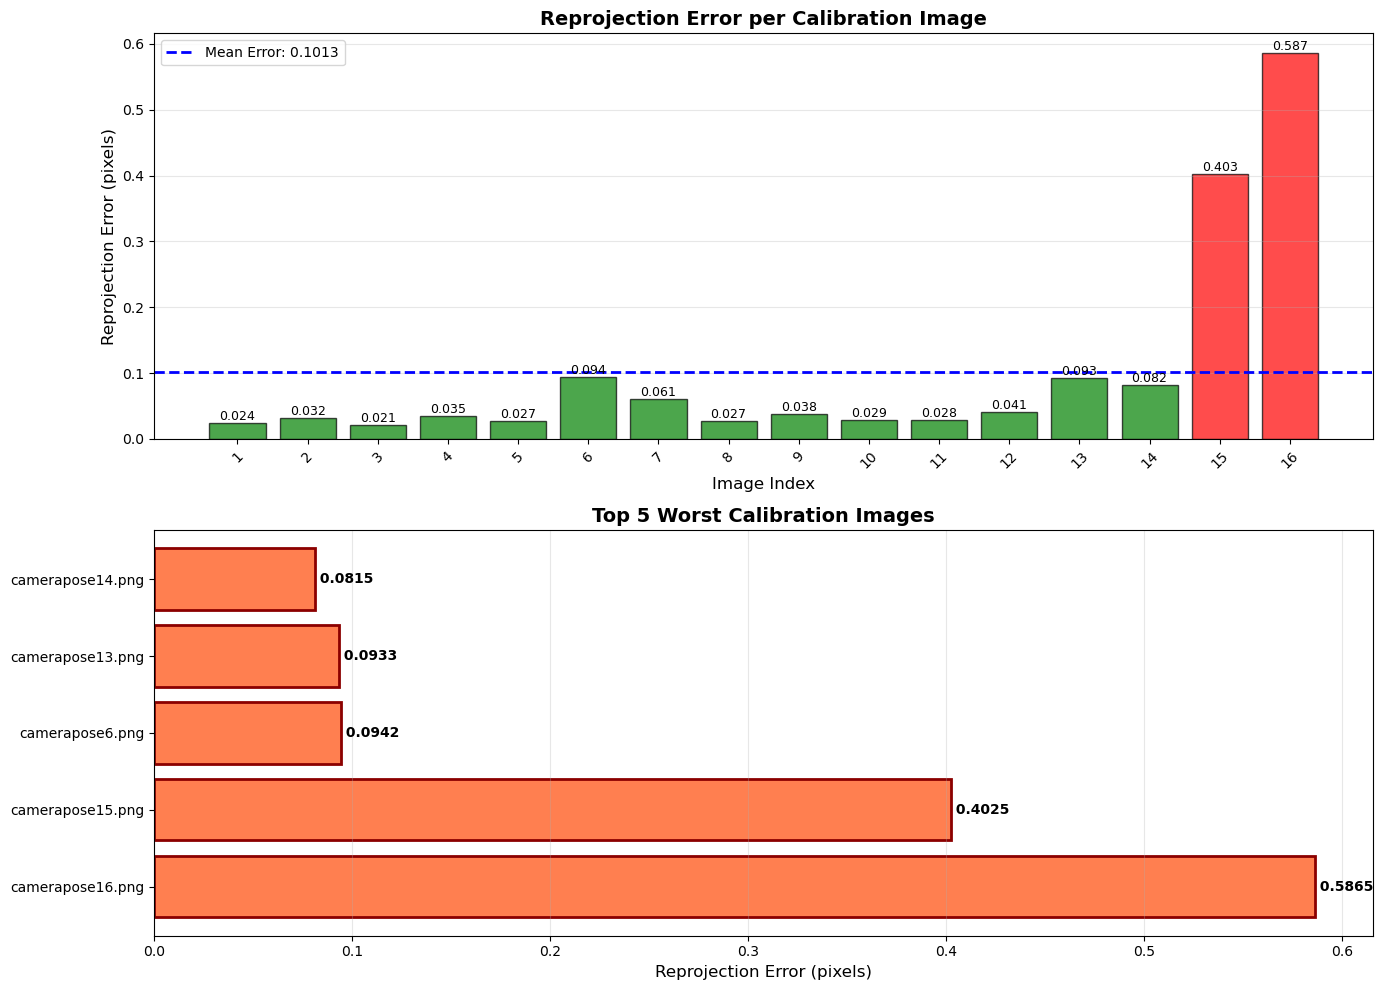


REPROJECTION ERROR SUMMARY

Image-by-image breakdown:
   1. camerapose1.png                  0.0240 px  ✓ Good
   2. camerapose2.png                  0.0319 px  ✓ Good
   3. camerapose3.png                  0.0214 px  ✓ Good
   4. camerapose4.png                  0.0352 px  ✓ Good
   5. camerapose5.png                  0.0266 px  ✓ Good
   6. camerapose6.png                  0.0942 px  ✓ Good
   7. camerapose7.png                  0.0609 px  ✓ Good
   8. camerapose8.png                  0.0275 px  ✓ Good
   9. camerapose9.png                  0.0375 px  ✓ Good
  10. camerapose10.png                 0.0286 px  ✓ Good
  11. camerapose11.png                 0.0283 px  ✓ Good
  12. camerapose12.png                 0.0412 px  ✓ Good
  13. camerapose13.png                 0.0933 px  ✓ Good
  14. camerapose14.png                 0.0815 px  ✓ Good
  15. camerapose15.png                 0.4025 px  ⚠ High
  16. camerapose16.png                 0.5865 px  ⚠ High

--------------------------------

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visualize reprojection errors
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Bar chart of errors per image
image_names = [os.path.basename(img) for img in images]
colors = ['red' if e > mean_error * 1.5 else 'orange' if e > mean_error else 'green' for e in errors_per_image]

ax = axes[0]
bars = ax.bar(range(len(errors_per_image)), errors_per_image, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=mean_error, color='blue', linestyle='--', linewidth=2, label=f'Mean Error: {mean_error:.4f}')
ax.set_xlabel('Image Index', fontsize=12)
ax.set_ylabel('Reprojection Error (pixels)', fontsize=12)
ax.set_title('Reprojection Error per Calibration Image', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend()
ax.set_xticks(range(len(errors_per_image)))
ax.set_xticklabels([str(i+1) for i in range(len(errors_per_image))], rotation=45)

# Add value labels on bars
for i, (bar, error) in enumerate(zip(bars, errors_per_image)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{error:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Worst images highlight
ax = axes[1]
sorted_indices = sorted(range(len(errors_per_image)), key=lambda i: errors_per_image[i], reverse=True)
worst_n = min(5, len(errors_per_image))
worst_indices = sorted_indices[:worst_n]

worst_names = [os.path.basename(images[i]) for i in worst_indices]
worst_errors = [errors_per_image[i] for i in worst_indices]

bars = ax.barh(range(worst_n), worst_errors, color='coral', edgecolor='darkred', linewidth=2)
ax.set_yticks(range(worst_n))
ax.set_yticklabels(worst_names, fontsize=10)
ax.set_xlabel('Reprojection Error (pixels)', fontsize=12)
ax.set_title(f'Top {worst_n} Worst Calibration Images', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, error) in enumerate(zip(bars, worst_errors)):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {error:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print error summary
print("\n" + "="*70)
print("REPROJECTION ERROR SUMMARY")
print("="*70)
print(f"\nImage-by-image breakdown:")
for i, (img, err) in enumerate(zip(image_names, errors_per_image)):
    status = "✓ Good" if err < mean_error else "⚠ High" if err > mean_error * 1.5 else "○ OK"
    print(f"  {i+1:2d}. {img:<30} {err:8.4f} px  {status}")

print(f"\n{'-'*70}")
print(f"{'Metric':<30} {'Value':>15}")
print(f"{'-'*70}")
print(f"{'Mean Error':<30} {mean_error:>15.4f} px")
print(f"{'Min Error':<30} {min(errors_per_image):>15.4f} px (Image {errors_per_image.index(min(errors_per_image))+1})")
print(f"{'Max Error':<30} {max(errors_per_image):>15.4f} px (Image {errors_per_image.index(max(errors_per_image))+1})")
print(f"{'Std Dev':<30} {np.std(errors_per_image):>15.4f} px")
print(f"{'-'*70}")
print(f"\nRecommendation: Images with error > {mean_error*1.5:.4f} px may need retaking.")
